# 음식점 그래프 탐색 및 MST 애니메이션

이 노트북은 음식점 간 이동 시간 데이터를 코드 안에 직접 넣고, 전체 그래프/DFS/BFS/프림/크루스칼 과정을 시각화합니다.
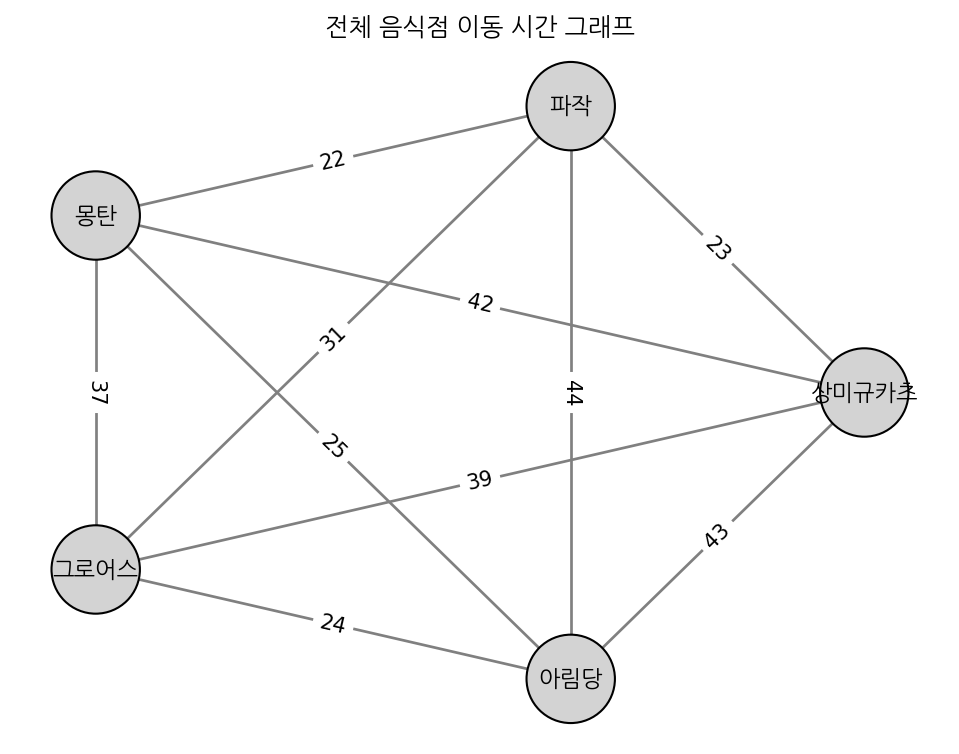

In [ ]:

# 음식점 그래프 탐색/최소신장트리 애니메이션
# 필요한 패키지: networkx, matplotlib, numpy

import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML, display

# -----------------------------
# 1. 데이터 입력: 별도 파일 없이 코드 안에 저장
# -----------------------------
restaurants = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]

# 표의 위쪽 삼각행렬 값을 사용해 무방향 그래프를 구성한다.
# 예: 상미규카츠-파작 = 23, 상미규카츠-몽탄 = 42 ...
edges = [
    ("상미규카츠", "파작", 23),
    ("상미규카츠", "몽탄", 42),
    ("상미규카츠", "그로어스", 39),
    ("상미규카츠", "아림당", 43),
    ("파작", "몽탄", 22),
    ("파작", "그로어스", 31),
    ("파작", "아림당", 44),
    ("몽탄", "그로어스", 37),
    ("몽탄", "아림당", 25),
    ("그로어스", "아림당", 24),
]

G = nx.Graph()
G.add_nodes_from(restaurants)
G.add_weighted_edges_from(edges)

# 고정 배치: 모든 그래프와 애니메이션이 같은 위치를 사용
pos = nx.circular_layout(G)

# -----------------------------
# 공통 그리기 함수
# -----------------------------
def draw_graph(highlight_nodes=None, highlight_edges=None, title="Graph", save_path=None):
    highlight_nodes = set(highlight_nodes or [])
    highlight_edges = {tuple(sorted(e)) for e in (highlight_edges or [])}

    node_colors = ["orange" if n in highlight_nodes else "lightgray" for n in G.nodes()]
    edge_colors = ["tomato" if tuple(sorted((u, v))) in highlight_edges else "gray" for u, v in G.edges()]
    widths = [3 if tuple(sorted((u, v))) in highlight_edges else 1.3 for u, v in G.edges()]

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, edgecolors="black")
    nx.draw_networkx_labels(G, pos, font_family="NanumGothic", font_size=11)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths)
    labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=10)
    plt.title(title)
    plt.axis("off")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()

# 전체 음식점 그래프 표시
draw_graph(title="전체 음식점 이동 시간 그래프", save_path="all_restaurants_graph.png")

# -----------------------------
# 애니메이션 공통 함수
# -----------------------------
def save_animation(frames, title, filename):
    fig, ax = plt.subplots(figsize=(8, 6))
    edge_labels = nx.get_edge_attributes(G, "weight")

    def update(i):
        ax.clear()
        frame = frames[i]
        visited_nodes = set(frame.get("nodes", []))
        selected_edges = {tuple(sorted(e)) for e in frame.get("edges", [])}
        current = frame.get("current")
        subtitle = frame.get("text", "")

        node_colors = []
        for n in G.nodes():
            if n == current:
                node_colors.append("tomato")
            elif n in visited_nodes:
                node_colors.append("orange")
            else:
                node_colors.append("lightgray")

        edge_colors = []
        widths = []
        for u, v in G.edges():
            if tuple(sorted((u, v))) in selected_edges:
                edge_colors.append("tomato")
                widths.append(3)
            else:
                edge_colors.append("gray")
                widths.append(1.2)

        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, edgecolors="black", ax=ax)
        nx.draw_networkx_labels(G, pos, font_family="NanumGothic", font_size=11, ax=ax)
        nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
        ax.set_title(f"{title}\n{subtitle}")
        ax.axis("off")

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000, repeat=False)
    writer = FFMpegWriter(fps=1, metadata={"artist": "networkx/matplotlib"}, bitrate=1800)
    anim.save(filename, writer=writer, dpi=150)
    plt.close(fig)
    print(f"saved: {filename}")
    return anim

# -----------------------------
# 2. DFS 애니메이션
# -----------------------------
def dfs_frames(graph, start):
    visited = set()
    frames = []
    tree_edges = []

    def dfs(node):
        visited.add(node)
        frames.append({"nodes": list(visited), "edges": list(tree_edges), "current": node,
                       "text": f"방문: {node}"})
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in visited:
                tree_edges.append(tuple(sorted((node, neighbor))))
                frames.append({"nodes": list(visited), "edges": list(tree_edges), "current": neighbor,
                               "text": f"{node} → {neighbor} 이동"})
                dfs(neighbor)

    dfs(start)
    return frames

dfs_anim = save_animation(dfs_frames(G, "상미규카츠"), "DFS 방문 과정", "dfs.mp4")

# -----------------------------
# 3. BFS 애니메이션
# -----------------------------
def bfs_frames(graph, start):
    visited = {start}
    queue = [start]
    frames = [{"nodes": list(visited), "edges": [], "current": start, "text": f"시작: {start}"}]
    tree_edges = []

    while queue:
        node = queue.pop(0)
        frames.append({"nodes": list(visited), "edges": list(tree_edges), "current": node,
                       "text": f"큐에서 꺼냄: {node}"})
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                tree_edges.append(tuple(sorted((node, neighbor))))
                frames.append({"nodes": list(visited), "edges": list(tree_edges), "current": neighbor,
                               "text": f"{node}의 인접 정점 발견: {neighbor}"})
    return frames

bfs_anim = save_animation(bfs_frames(G, "상미규카츠"), "BFS 방문 과정", "bfs.mp4")

# -----------------------------
# 4. 프림 알고리즘 MST 애니메이션
# -----------------------------
def prim_frames(graph, start):
    visited = {start}
    mst_edges = []
    frames = [{"nodes": list(visited), "edges": list(mst_edges), "current": start,
               "text": f"시작: {start}"}]

    while len(visited) < len(graph.nodes()):
        candidates = []
        for u in visited:
            for v in graph.neighbors(u):
                if v not in visited:
                    candidates.append((graph[u][v]["weight"], u, v))
        weight, u, v = min(candidates)
        visited.add(v)
        mst_edges.append(tuple(sorted((u, v))))
        frames.append({"nodes": list(visited), "edges": list(mst_edges), "current": v,
                       "text": f"선택: {u}-{v}, 가중치 {weight}"})
    return frames

prim_anim = save_animation(prim_frames(G, "상미규카츠"), "프림 알고리즘 MST 생성 과정", "prim.mp4")

# -----------------------------
# 5. 크루스칼 알고리즘 MST 애니메이션
# -----------------------------
def kruskal_frames(graph):
    parent = {n: n for n in graph.nodes()}
    rank = {n: 0 for n in graph.nodes()}
    mst_edges = []
    visited_nodes = set()
    frames = [{"nodes": [], "edges": [], "current": None, "text": "가중치가 작은 간선부터 검사"}]

    def find(x):
        if parent[x] != x:
            parent[x] = find(parent[x])
        return parent[x]

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return False
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1
        return True

    sorted_edges = sorted(graph.edges(data=True), key=lambda x: x[2]["weight"])
    for u, v, data in sorted_edges:
        w = data["weight"]
        if union(u, v):
            mst_edges.append(tuple(sorted((u, v))))
            visited_nodes.update([u, v])
            frames.append({"nodes": list(visited_nodes), "edges": list(mst_edges), "current": v,
                           "text": f"추가: {u}-{v}, 가중치 {w}"})
        else:
            frames.append({"nodes": list(visited_nodes), "edges": list(mst_edges), "current": None,
                           "text": f"제외: {u}-{v}, 사이클 발생"})
        if len(mst_edges) == len(graph.nodes()) - 1:
            break
    return frames

kruskal_anim = save_animation(kruskal_frames(G), "크루스칼 알고리즘 MST 생성 과정", "kruskal.mp4")

# MST 결과 확인
prim_mst_edges = prim_frames(G, "상미규카츠")[-1]["edges"]
kruskal_mst_edges = kruskal_frames(G)[-1]["edges"]
print("Prim MST edges:", prim_mst_edges)
print("Kruskal MST edges:", kruskal_mst_edges)
print("MST total weight:", sum(G[u][v]["weight"] for u, v in prim_mst_edges))
